<div align="center">

# Trabajo Práctico: Predicción de Precios de Casas

**Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA)**

</div>

---

**Integrantes:** 
* Aiup, Agustín.
* Paoloni, Franco.
* Silva, Julián.

---

## Librerias y Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Mostramos todas las columnas y limitamos los decimales para que las tablas sean legibles.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Estilo uniforme para todos los gráficos del notebook.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Semilla global: la reutilizamos en cada paso aleatorio para que el trabajo sea reproducible.
RANDOM_STATE = 42

In [2]:
house_pricing = pd.read_csv("../data/house-prices-tp.csv")

## Análisis Exploratorio

En esta sección se elabora un primer diagnóstico del conjunto de datos.

### Estructura General

In [3]:
house_pricing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.072,0.000,4.490,0.000,0.449,6.121,56.800,3.748,3.000,247.000,18.500,395.150,8.440,22.200
1,0.083,0.000,13.920,0.000,0.437,6.127,18.400,5.503,4.000,289.000,16.000,396.900,8.580,23.900
2,0.128,12.500,6.070,0.000,0.409,5.885,33.000,6.498,4.000,345.000,18.900,396.900,8.790,20.900
3,0.089,21.000,5.640,0.000,0.439,5.963,45.700,6.815,4.000,243.000,16.800,395.560,13.450,19.700
4,0.114,0.000,8.560,0.000,0.520,6.781,71.300,2.856,5.000,384.000,20.900,395.580,7.670,26.500


In [4]:
house_pricing.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


### Estadísticos Descriptivos

In [5]:
house_pricing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.000,534.000,541.000,533.000,532.000,535.000,532.000,541.000,528.000,538.000,528.000,534.000,534.000,535.000
mean,5.846,13.197,11.219,0.090,0.560,6.292,67.632,3.944,9.699,409.575,18.430,347.806,13.028,22.747
std,13.829,24.903,6.942,0.287,0.119,0.782,28.462,2.256,8.684,167.689,2.195,99.636,7.580,9.491
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.084,0.000,5.130,0.000,0.453,5.876,42.275,2.112,4.000,279.000,17.000,369.530,7.150,16.750
50%,0.315,0.000,9.690,0.000,0.538,6.208,76.500,3.340,5.000,335.000,19.000,390.815,11.465,21.200
75%,4.871,20.000,18.100,0.000,0.644,6.639,93.825,5.401,23.633,666.000,20.200,395.890,17.205,26.300
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.127,24.000,711.000,22.000,396.900,37.970,50.000


### Análisis de valores faltantes

Primero se analiza si la variable a predecir `MEDV` tiene datos faltantes. De ser así, procedemos a eliminar aquellas filas en lugar de imputar los datos, dado que no se cuenta con la etiqueta de respuesta para entrenar el modelo.

In [6]:
print(f"La variable de respuesta 'MEDV' tiene {house_pricing['MEDV'].isna().sum()} datos faltantes.")

# Procedemos a eliminar los datos faltantes
house_pricing = house_pricing.dropna(subset = ['MEDV'])
print(f"\n El DataFrame ahora tiene {len(house_pricing)} observaciones.")

La variable de respuesta 'MEDV' tiene 21 datos faltantes.

 El DataFrame ahora tiene 535 observaciones.


Con el nuevo dataset, procedemos a analizar los datos faltantes que restan:

* Total de valores faltantes.
* Total de valores faltantes por variable (columnas).
* Total de valores faltantes por observacion (fila).


 Total de valores faltantes : 115

 Total de valores faltantes (por variable): 
   variable  nulos_x_variable  proporcion
0       RAD                12       2.243
1      CRIM                11       2.056
2       AGE                11       2.056
3        ZN                11       2.056
4      CHAS                 9       1.682
5       NOX                 9       1.682
6     LSTAT                 9       1.682
7         B                 9       1.682
8       TAX                 9       1.682
9   PTRATIO                 9       1.682
10       RM                 7       1.308
11      DIS                 5       0.935
12    INDUS                 4       0.748
13     MEDV                 0       0.000

 Total de filas con datos faltantes: 29

 Filas con datos faltantes: 
     nro_fila  nulos_x_obs  proporcion
0         88            9      64.286
1        248            8      57.143
2        504            8      57.143
3        223            7      50.000
4        234            7  

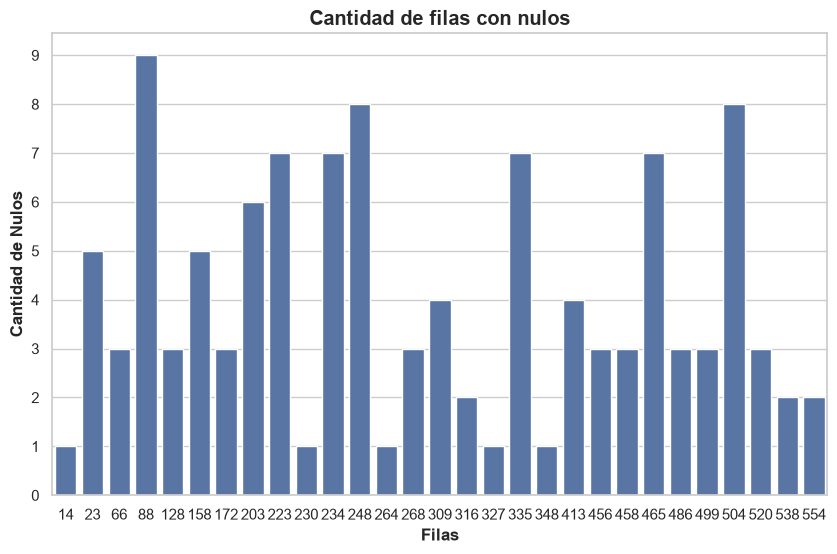

Promedio de faltantes por fila: 4.0


In [ ]:
# Total de valores faltantes
total_nulos = (house_pricing.isna().sum().sum())

# Total de valores faltantes por variable (columnas):
total_nulos_variable = pd.DataFrame({
    'nulos_x_variable' : house_pricing.isna().sum(),
    'proporcion' : ((house_pricing.isna().sum() / len(house_pricing)) * 100)
    }).sort_values(by = 'proporcion', ascending = False)

total_nulos_variable = total_nulos_variable.reset_index()
total_nulos_variable = total_nulos_variable.rename(columns = {'index' : 'variable'})

# Total de valores faltantes por observación (filas):
total_nulos_filas = pd.DataFrame({
    'nulos_x_obs' : house_pricing.isna().sum(axis = 1),
    'proporcion' :  ((house_pricing.isna().sum(axis = 1) / house_pricing.shape[1])*100)
}).sort_values(by = 'proporcion', ascending = False)

total_nulos_filas = total_nulos_filas[total_nulos_filas['proporcion'] > 0]
total_nulos_filas = total_nulos_filas.reset_index()
total_nulos_filas = total_nulos_filas.rename(columns = {'index' : 'nro_fila'})


print(f"\n Total de valores faltantes : {total_nulos}")
print(f"\n Total de valores faltantes (por variable): \n{total_nulos_variable}")
print(f"\n Total de filas con datos faltantes: {len(total_nulos_filas)}")
print(f"\n Filas con datos faltantes: \n {total_nulos_filas}")
print(f"Promedio de faltantes por fila: {total_nulos_filas['nulos_x_obs'].mean().round(0)}")


# Graficamos la cantidad de las filas con faltantes

y_ticks = np.arange(0, 10, 1)

fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(total_nulos_filas, x = 'nro_fila', y = 'nulos_x_obs')
ax.set_title('Cantidad de filas con nulos', fontweight = 'bold', size = 'large')
ax.set_xlabel('Filas', fontweight = 'bold')
ax.set_ylabel('Cantidad de Nulos', fontweight = 'bold')
ax.set_yticks(y_ticks)
plt.show()

Se observa que 29 filas de 535 presentan valores faltantes (aprox. 5% de las observaciones restantes). A su vez, en promedio faltan 4 de las 13 variables predictoras por fila, es decir casi un tercio de cada observación afectada.

Imputar consiste en estimar el valor faltante a partir del resto de la información de esa misma fila y del conjunto. Con ese nivel de deterioro queda poca información sobre la cual apoyar la estimación: esas filas entrarían al modelo con más valores construidos por nosotros que medidos, y pesarían igual que las reales durante el ajuste. Como además representan apenas el 5% de los datos, el costo de eliminarlas es bajo frente al riesgo de sesgar el modelo imputándolas.

In [8]:
house_pricing = house_pricing.dropna()

print(f"El DataFrame ahora quedó con {house_pricing.shape[0]} observaciones y {house_pricing.shape[1]} variables.")

El DataFrame ahora quedó con 506 observaciones y 14 variables.
